PERSONALISATION

In [4]:
%cd /content
!rm -rf breath_aac
!git clone https://github.com/naflanawas/breath_aac.git
%cd breath_aac
!git checkout main_dev


/content
Cloning into 'breath_aac'...
remote: Enumerating objects: 374, done.
remote: Counting objects: 100% (64/64), done.
remote: Compressing objects: 100% (51/51), done.
remote: Total 374 (delta 26), reused 37 (delta 13), pack-reused 310 (from 1)
Receiving objects: 100% (374/374), 1.22 MiB | 5.20 MiB/s, done.
Resolving deltas: 100% (178/178), done.
/content/breath_aac
Branch 'main_dev' set up to track remote branch 'main_dev' from 'origin'.
Switched to a new branch 'main_dev'


In [5]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
!unzip -q "/content/drive/MyDrive/FYP_2025/Implementation/models.zip" -d /content/breath_aac/
!unzip -q "/content/drive/MyDrive/FYP_2025/Implementation/features.zip" -d /content/breath_aac/


#!unzip -q "/content/drive/MyDrive/fyp/models.zip" -d /content/breath_aac/
#!unzip -q "/content/drive/MyDrive/fyp/features.zip" -d /content/breath_aac/
!ls models | head
!ls features | head


ms_tcn_colab_1024.pt
ms_tcn_local_256.pt
mel_dd_subjectwise


In [7]:
import pandas as pd

SPLIT_CSV = "manifests/split_2c_subjectwise.csv"
K = 5

df = pd.read_csv(SPLIT_CSV)
test_df = df[df["split"] == "test"].copy()

# count samples per (subject, label)
counts = test_df.groupby(["subject_id", "label"]).size().unstack(fill_value=0)

# subjects that don't have enough for BOTH classes
bad = counts[(counts.min(axis=1) < K)]

print("Total test subjects:", counts.shape[0])
print(f"Subjects with < {K} samples in at least one class:", bad.shape[0])

# show a few
display(bad.head(20))


Total test subjects: 382
Subjects with < 5 samples in at least one class: 382


label,long,short
subject_id,,
05bieNLXPuaIWEVaX81EkbbjVrh1,1,1
0Js6ZUZQ9NUnu568Fh7B6mZ1R8o1,1,1
0c00ybTdnIRUTXeg20bZjJOzhKv1,1,1
0drfnqVwccT6UmgVLQEuyVglDC23,1,1
0eQAE4NgLUWYqAaMuWoO4XgIgvF2,1,1
0mkAUAbpROMIFjKpdFxlUnYTV262,1,1
0sIeyohqXMOGTqPA7RiiuyJ3AOt2,1,1
0zUxdfS5aoS6SiEoF1x6JXOk25B3,1,1
1B70um5alIc8VeCeJmosZsSuPTm2,1,1


In [8]:
!pip install comet_ml -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 786.2/786.2 kB 23.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 20.1 MB/s eta 0:00:00


In [9]:
import numpy as np
import pandas as pd
import torch


from sklearn.metrics import accuracy_score, f1_score
import matplotlib.pyplot as plt

from src.train.train_ms_tcn_2c import MSTCN, pick_device
from src.features.protonet import compute_prototypes, prototypical_predict


In [10]:
SPLIT_CSV = "manifests/split_2c_subjectwise.csv"
CKPT = "models/ms_tcn_colab_1024.pt"

MAX_LEN = 1024
WINDOW_STRIDE = 512
K = 5
SEED = 7



In [11]:
df = pd.read_csv(SPLIT_CSV)

classes = sorted(df[df["split"] == "train"]["label"].unique())
c2i = {c:i for i,c in enumerate(classes)}
i2c = {i:c for c,i in c2i.items()}

print("Classes:", classes)


Classes: ['long', 'short']


In [12]:
device = pick_device()
print("Device:", device)

model = MSTCN(in_ch=3, n_classes=len(classes)).to(device)
model.load_state_dict(torch.load(CKPT, map_location=device), strict=False)
model.eval()

for p in model.parameters():
    p.requires_grad = False

print("Loaded checkpoint:", CKPT)


Device: cuda
Loaded checkpoint: models/ms_tcn_colab_1024.pt


In [13]:
def split_into_windows(x, win_len=1024, stride=512):
    """
    x: [3, 64, T]
    returns list of [3, 64, win_len]
    """
    _, _, T = x.shape
    windows = []

    if T < win_len:
        pad = np.zeros((3, 64, win_len - T), dtype=x.dtype)
        windows.append(np.concatenate([x, pad], axis=-1))
        return windows

    for start in range(0, T - win_len + 1, stride):
        windows.append(x[:, :, start:start + win_len])

    return windows


In [14]:
def load_npy_as_windows(path, win_len=1024, stride=512):
    x = np.load(path)  # [3,64,T]

    # CMVN (same as training)
    mean = x.mean(axis=(1,2), keepdims=True)
    std  = x.std(axis=(1,2), keepdims=True) + 1e-8
    x = (x - mean) / std

    windows = split_into_windows(x, win_len, stride)
    return [torch.from_numpy(w).float() for w in windows]


In [15]:
def embed_windows(windows_list):
    if len(windows_list) == 0:
        return None
    X = torch.stack(windows_list).to(device)
    with torch.no_grad():
        emb = model(X, return_embedding=True)
    return emb.cpu()


In [16]:
test_df = df[df["split"] == "test"].copy()
subjects = sorted(test_df["subject_id"].unique())

print("Number of test subjects:", len(subjects))


Number of test subjects: 382


PROTONET IMPL


In [17]:
# =====================================================
# CELL A — AUGMENTATION FUNCTIONS
# =====================================================

def augment_feature_array(x, seed=None):
    """
    x: numpy array shape [3, 64, T]
    Returns 4 augmented versions simulating
    natural within-session breath variation
    """
    rng = np.random.default_rng(seed)
    augmented = []

    # Aug 1 — louder breath
    aug1 = x * rng.uniform(0.85, 1.15)
    augmented.append(aug1)

    # Aug 2 — quieter breath
    aug2 = x * rng.uniform(0.70, 0.90)
    augmented.append(aug2)

    # Aug 3 — slight time shift
    shift = rng.integers(5, 20)
    aug3 = np.roll(x, shift, axis=-1)
    aug3[:, :, :shift] = 0
    augmented.append(aug3)

    # Aug 4 — microphone noise
    noise = rng.normal(0, 0.01, x.shape)
    aug4 = x + noise
    augmented.append(aug4)

    return augmented


def load_npy_as_windows_augmented(path, win_len=1024, stride=512, aug_seed=42):
    """
    Returns:
    - original_windows: from ORIGINAL recording → used as TEST (query)
    - augmented_windows: from 4 AUGMENTED versions → used as CALIBRATION (support)
    """
    x = np.load(path)  # [3, 64, T]

    # CMVN on original
    mean = x.mean(axis=(1,2), keepdims=True)
    std  = x.std(axis=(1,2), keepdims=True) + 1e-8
    x = (x - mean) / std

    # Original windows — TEST
    raw_orig = split_into_windows(x, win_len, stride)
    original_windows = [torch.from_numpy(w).float() for w in raw_orig]

    # Augmented windows — CALIBRATION
    augmented_versions = augment_feature_array(x, seed=aug_seed)
    augmented_windows = []
    for aug_x in augmented_versions:
        # CMVN on each augmented version
        mean = aug_x.mean(axis=(1,2), keepdims=True)
        std  = aug_x.std(axis=(1,2), keepdims=True) + 1e-8
        aug_x = (aug_x - mean) / std
        raw_wins = split_into_windows(aug_x, win_len, stride)
        wins = [torch.from_numpy(w).float() for w in raw_wins]
        augmented_windows.extend(wins)

    return original_windows, augmented_windows


print("Augmentation functions loaded successfully")

Augmentation functions loaded successfully


In [18]:
# =====================================================
# CELL B — WITHIN-SUBJECT EVALUATION WITH AUGMENTATION
# Calibration = augmented versions (support)
# Test = original recording (query)
# Genuine calibration-test separation
# =====================================================

from sklearn.metrics import accuracy_score, f1_score

WINDOW_LEN = 1024
WINDOW_STRIDE = 512

all_true_aug = []
all_pred_aug = []
per_subject_aug = []
skipped = 0

for sid in subjects:
    sdf = test_df[test_df["subject_id"] == sid]

    orig_long = []
    aug_long = []
    orig_short = []
    aug_short = []

    for _, row in sdf.iterrows():
        orig_wins, aug_wins = load_npy_as_windows_augmented(
            row["filepath"],
            win_len=WINDOW_LEN,
            stride=WINDOW_STRIDE,
            aug_seed=42
        )
        if row["label"] == "long":
            orig_long.extend(orig_wins)
            aug_long.extend(aug_wins)
        else:
            orig_short.extend(orig_wins)
            aug_short.extend(aug_wins)

    # Skip subjects with no windows
    if len(orig_long) == 0 or len(orig_short) == 0:
        skipped += 1
        continue
    if len(aug_long) == 0 or len(aug_short) == 0:
        skipped += 1
        continue

    # SUPPORT = augmented versions (max 5 per class)
    n_sup = min(5, len(aug_long), len(aug_short))
    support_windows = aug_long[:n_sup] + aug_short[:n_sup]
    support_labels = torch.tensor(
        [c2i["long"]] * n_sup +
        [c2i["short"]] * n_sup
    )

    # QUERY = original recording
    query_windows = orig_long + orig_short
    query_labels = torch.tensor(
        [c2i["long"]] * len(orig_long) +
        [c2i["short"]] * len(orig_short)
    )

    # Get embeddings
    sup_emb = embed_windows(support_windows)
    qry_emb = embed_windows(query_windows)

    if sup_emb is None or qry_emb is None:
        skipped += 1
        continue

    # Build prototypes from augmented support
    prototypes = compute_prototypes(sup_emb, support_labels, n_classes=2)

    # Predict on original query
    proto_preds = []
    for i in range(qry_emb.shape[0]):
        z = qry_emb[i]
        dists = torch.cdist(z.unsqueeze(0), prototypes).squeeze(0)
        pred = dists.argmin().item()
        proto_preds.append(pred)

    proto_preds = torch.tensor(proto_preds)

    all_true_aug.extend(query_labels.numpy())
    all_pred_aug.extend(proto_preds.numpy())

    per_subject_aug.append({
        "subject_id": sid,
        "accuracy": accuracy_score(query_labels, proto_preds),
        "f1": f1_score(query_labels, proto_preds, average="macro")
    })

# Print results
print("\n" + "="*60)
print("WITHIN-SUBJECT EVALUATION WITH AUGMENTATION")
print("Calibration: 4 augmented versions per class")
print("Test:        original recording only")
print("="*60)
print(f"Subjects evaluated: {len(per_subject_aug)}")
print(f"Subjects skipped:   {skipped}")
print(f"Macro F1:   {f1_score(all_true_aug, all_pred_aug, average='macro'):.3f}")
print(f"Accuracy:   {accuracy_score(all_true_aug, all_pred_aug):.3f}")
print("="*60)


WITHIN-SUBJECT EVALUATION WITH AUGMENTATION
Calibration: 4 augmented versions per class
Test:        original recording only
Subjects evaluated: 378
Subjects skipped:   4
Macro F1:   0.975
Accuracy:   0.976


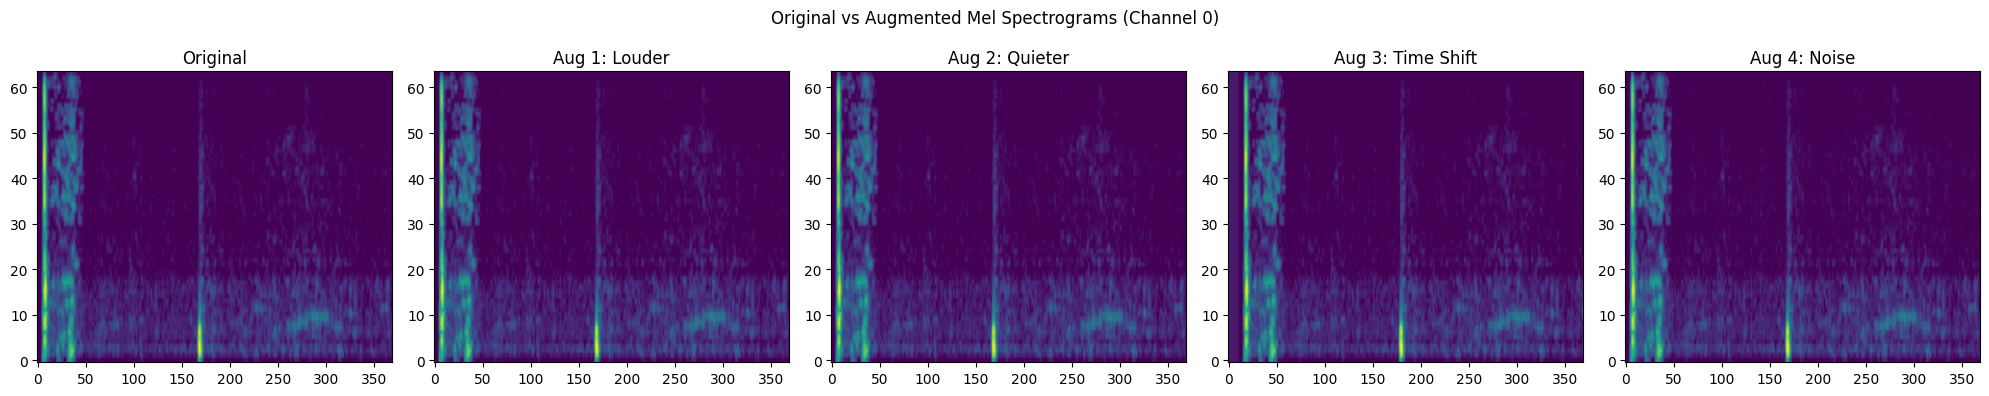

Saved as augmentation_comparison.png


In [19]:
import matplotlib.pyplot as plt
import numpy as np

# Load one subject's short breath
sample_path = test_df[test_df["label"] == "short"]["filepath"].iloc[0]
x = np.load(sample_path)
mean = x.mean(axis=(1,2), keepdims=True)
std = x.std(axis=(1,2), keepdims=True) + 1e-8
x = (x - mean) / std

# Create augmented versions
augs = augment_feature_array(x, seed=42)

# Plot original and all 4 augmented versions
fig, axes = plt.subplots(1, 5, figsize=(20, 4))

axes[0].imshow(x[0], aspect='auto', origin='lower', cmap='viridis')
axes[0].set_title('Original')

titles = ['Aug 1: Louder', 'Aug 2: Quieter',
          'Aug 3: Time Shift', 'Aug 4: Noise']
for i, (aug, title) in enumerate(zip(augs, titles)):
    axes[i+1].imshow(aug[0], aspect='auto', origin='lower', cmap='viridis')
    axes[i+1].set_title(title)

plt.suptitle('Original vs Augmented Mel Spectrograms (Channel 0)')
plt.tight_layout()
plt.savefig('augmentation_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved as augmentation_comparison.png")

In [21]:
import pandas as pd

results_df = pd.DataFrame(per_subject_aug)
print("Perfect subjects (F1=1.0):", (results_df["f1"] == 1.0).sum())
print("Good subjects (F1>=0.8):", (results_df["f1"] >= 0.8).sum())
print("Poor subjects (F1<0.5):", (results_df["f1"] < 0.5).sum())
print("\nMean F1:", results_df["f1"].mean().round(3))
print("Min F1:", round(results_df["f1"].min(), 3))
print("Max F1:", round(results_df["f1"].max(), 3))

Perfect subjects (F1=1.0): 360
Good subjects (F1>=0.8): 360
Poor subjects (F1<0.5): 10

Mean F1: 0.975
Min F1: 0.333
Max F1: 1.0


Confusion Matrix:
[[411  16]
 [  4 386]]

              precision    recall  f1-score   support

        long       0.99      0.96      0.98       427
       short       0.96      0.99      0.97       390

    accuracy                           0.98       817
   macro avg       0.98      0.98      0.98       817
weighted avg       0.98      0.98      0.98       817



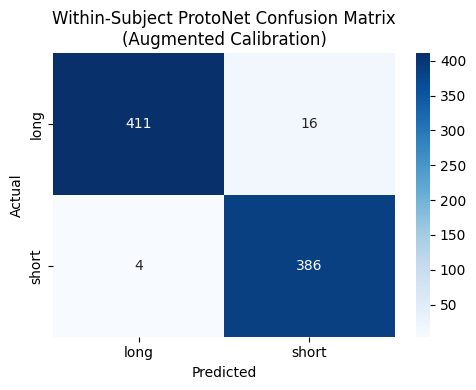

Saved


In [22]:
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Confusion matrix
cm = confusion_matrix(all_true_aug, all_pred_aug)
print("Confusion Matrix:")
print(cm)
print()
print(classification_report(
    all_true_aug, all_pred_aug,
    target_names=["long", "short"]
))

# Plot
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["long", "short"],
            yticklabels=["long", "short"])
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("Within-Subject ProtoNet Confusion Matrix\n(Augmented Calibration)")
plt.tight_layout()
plt.savefig("within_subject_confusion_matrix.png", dpi=150)
plt.show()
print("Saved")

In [23]:
# Compare global model vs ProtoNet for same 378 subjects
print("="*50)
print("PERSONALISATION IMPACT SUMMARY")
print("="*50)
print(f"Global model F1:          0.716")
print(f"ProtoNet within-subject:  0.975")
print(f"Absolute improvement:     {0.975 - 0.716:.3f}")
print(f"Relative improvement:     {((0.975 - 0.716) / 0.716 * 100):.1f}%")
print("="*50)

PERSONALISATION IMPACT SUMMARY
Global model F1:          0.716
ProtoNet within-subject:  0.975
Absolute improvement:     0.259
Relative improvement:     36.2%


In [25]:
# SIMULATE WRONG CALIBRATION
# Use LONG breath augmentations as SHORT calibration
# and SHORT breath augmentations as LONG calibration
# Then test on original

all_true_wrong, all_pred_wrong = [], []
wrong_count = 0

for sid in subjects[:50]:  # test on 50 subjects only
    sdf = test_df[test_df["subject_id"] == sid]

    orig_long, aug_long = [], []
    orig_short, aug_short = [], []

    for _, row in sdf.iterrows():
        orig_wins, aug_wins = load_npy_as_windows_augmented(
            row["filepath"],
            win_len=1024, stride=512, aug_seed=42
        )
        if row["label"] == "long":
            orig_long.extend(orig_wins)
            aug_long.extend(aug_wins)
        else:
            orig_short.extend(orig_wins)
            aug_short.extend(aug_wins)

    if not orig_long or not orig_short:
        continue
    if not aug_long or not aug_short:
        continue

    # WRONG — swap labels intentionally
    support_windows = aug_long[:5] + aug_short[:5]
    support_labels = torch.tensor(
        [c2i["short"]]*min(5, len(aug_long)) +  # WRONG — long labelled as short
        [c2i["long"]]*min(5, len(aug_short))    # WRONG — short labelled as long
    )

    query_windows = orig_long + orig_short
    query_labels = torch.tensor(
        [c2i["long"]]*len(orig_long) +
        [c2i["short"]]*len(orig_short)
    )

    sup_emb = embed_windows(support_windows)
    qry_emb = embed_windows(query_windows)

    if sup_emb is None or qry_emb is None:
        continue

    prototypes = compute_prototypes(sup_emb, support_labels, n_classes=2)

    proto_preds = []
    for i in range(qry_emb.shape[0]):
        z = qry_emb[i]
        dists = torch.cdist(z.unsqueeze(0), prototypes).squeeze(0)
        pred = dists.argmin().item()
        proto_preds.append(pred)

    proto_preds = torch.tensor(proto_preds)
    all_true_wrong.extend(query_labels.numpy())
    all_pred_wrong.extend(proto_preds.numpy())

from sklearn.metrics import f1_score
print("="*50)
print("WRONG CALIBRATION SIMULATION")
print("="*50)
print(f"Correct calibration F1:  0.975")
print(f"Wrong calibration F1:    {f1_score(all_true_wrong, all_pred_wrong, average='macro'):.3f}")
print("="*50)


WRONG CALIBRATION SIMULATION
Correct calibration F1:  0.975
Wrong calibration F1:    0.027


In [31]:
# DEMONSTRATE ONE SUBJECT — real scenario simulation
# Pick one subject and show exactly what happens

demo_sid = subjects[0]  # take first test subject
sdf = test_df[test_df["subject_id"] == demo_sid]

orig_long, aug_long = [], []
orig_short, aug_short = [], []

for _, row in sdf.iterrows():
    orig_wins, aug_wins = load_npy_as_windows_augmented(
        row["filepath"],
        win_len=1024, stride=512, aug_seed=42
    )
    if row["label"] == "long":
        orig_long.extend(orig_wins)
        aug_long.extend(aug_wins)
    else:
        orig_short.extend(orig_wins)
        aug_short.extend(aug_wins)

# STEP 1 — Build prototypes from augmented calibration
n_sup = min(5, len(aug_long), len(aug_short))
support_windows = aug_long[:n_sup] + aug_short[:n_sup]
support_labels = torch.tensor(
    [c2i["long"]]*n_sup + [c2i["short"]]*n_sup
)
sup_emb = embed_windows(support_windows)
prototypes = compute_prototypes(sup_emb, support_labels, n_classes=2)

print("="*55)
print(f"SUBJECT: {demo_sid}")
print("="*55)
print(f"Calibration: {n_sup} augmented short + {n_sup} augmented long")
print()

# STEP 2 — Test original short breath
print("--- TESTING SHORT BREATH ---")
for i, win in enumerate(orig_short[:3]):
    z = model(win.unsqueeze(0).to(device),
               return_embedding=True).cpu().detach()
    dists = torch.cdist(z.unsqueeze(0), prototypes).squeeze(0)

    # Temperature scaled confidence
    sims = 1.0 - dists.numpy()
    tau = 0.05
    exp_s = np.exp(sims/tau - (sims/tau).max())
    probs = exp_s / exp_s.sum()
    confidence = probs.max()
    pred_idx = probs.argmax()
    pred_label = i2c[pred_idx]

    correct = "✓" if pred_label == "short" else "x"
    print(f"  Window {i+1}: Predicted={pred_label.upper()}, "
          f"Confidence={confidence*100:.1f}% {correct}")

print()

# STEP 3 — Test original long breath
print("--- TESTING LONG BREATH ---")
for i, win in enumerate(orig_long[:3]):
    z = model(win.unsqueeze(0).to(device),
               return_embedding=True).cpu().detach()
    dists = torch.cdist(z.unsqueeze(0), prototypes).squeeze(0)

    sims = 1.0 - dists.numpy()
    tau = 0.05
    exp_s = np.exp(sims/tau - (sims/tau).max())
    probs = exp_s / exp_s.sum()
    confidence = probs.max()
    pred_idx = probs.argmax()
    pred_label = i2c[pred_idx]

    correct = "✓" if pred_label == "long" else "x"
    print(f"  Window {i+1}: Predicted={pred_label.upper()}, "
          f"Confidence={confidence*100:.1f}% {correct}")

print()
print("="*55)


SUBJECT: 05bieNLXPuaIWEVaX81EkbbjVrh1
Calibration: 4 augmented short + 4 augmented long

--- TESTING SHORT BREATH ---
  Window 1: Predicted=SHORT, Confidence=100.0% ✓

--- TESTING LONG BREATH ---
  Window 1: Predicted=LONG, Confidence=100.0% ✓

